# Gaming Toxicity Detection - ML Pipeline
**Authors:** Beibarys Nyussupov, Ruby Ngo, Paola Calle, Jett Forward

**Pipeline overview:**
1. **Oversampling comparison** — compare RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN via 5-fold stratified CV with a reference LR.
2. **Model comparison** — tune LR (`LogisticRegressionCV`), Naive Bayes, LinearSVC (Optuna TPE) with BorderlineSMOTE; select best by CV macro F1.
3. **Test evaluation** — single held-out run on test set with best model.
4. **Interpretability** — feature weights per class, per-class metrics, error analysis.

**Design principles:**
- All parameters in `CONFIG` — nothing hardcoded elsewhere.
- `ImbPipeline` keeps oversampling inside each CV fold (no leakage).
- Train + Val combined into one training set — CV replaces the need for a separate validation split.

## 0. Imports & Configuration

In [47]:
# libraries 
import warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')

import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler

pd.set_option('display.max_columns', None)
plt.rcParams.update({'figure.dpi': 100})

In [2]:
# config
CONFIG = {
    'seed': 7524,
    'data_dir': Path('../data/processed_data'),
    'text_col': 'clean_message',
    'label_col': 'label',
    'cv_folds': 5,
    'scoring': 'f1_macro',        # macro = every class counts equally
    'optuna_trials': 30,
    'n_top_features': 20,
    'tfidf': dict(
        ngram_range=(1, 2),              # unigrams + bigrams: captures 'shut up', 'kill yourself'
        min_df=3,                        # drop terms in <3 docs (typos, player names)
        max_df=0.95,                     # drop near-universal terms
        sublinear_tf=True,               # log(1+tf): compresses repeated-word noise
        norm='l2',                       # L2-normalise -> dot product = cosine similarity
    ),
    'class_map': {
        0: 'Non-Toxic',
        1: 'Insults/Flaming',
        2: 'Other Offensive',
        3: 'Hate/Harassment',
        4: 'Threats',
        5: 'Extremism',
    },
}

# seed 
np.random.seed(CONFIG['seed'])
seed = CONFIG['seed']

# classes
class_map = CONFIG['class_map']
class_names = [class_map[i] for i in sorted(class_map)]

# cv
cv = StratifiedKFold(n_splits=CONFIG['cv_folds'], 
                     shuffle=True, 
                     random_state=seed)

# print
print('CONFIG loaded. Classes:', class_names)

CONFIG loaded. Classes: ['Non-Toxic', 'Insults/Flaming', 'Other Offensive', 'Hate/Harassment', 'Threats', 'Extremism']


In [55]:
# start study optuna bayes optimization
def start_study_optuna(objective, n_trials, seed, direction='maximize'):
    # sampler
    sampler = TPESampler(seed=seed)

    # start study
    study = optuna.create_study(direction=direction, sampler=sampler)

    # start optimization
    study.optimize(objective, n_trials=n_trials)
    print(f'Best params: {study.best_params}')
    return study

# multi class score 
def score_multiclass(model, X_train, X_test, y_train, y_test):
    """Fit model on train, evaluate on test - returns classification_report + scores."""

    # fit the model
    model.fit(X_train, y_train)

    # predict 
    y_pred = model.predict(X_test)

    # classification report 
    print("Test classification report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

## 1. Load Data

In [4]:
# data 
d = CONFIG['data_dir']
tc, lc = CONFIG['text_col'], CONFIG['label_col']

# train
train_df = pd.read_parquet(d / 'wot_train_ml.parquet')

# test 
test_df  = pd.read_parquet(d / 'wot_val_ml.parquet')   # val = out-of-sample test

# get the data 
X_train, y_train = train_df[tc], train_df[lc].astype(int)
X_test,  y_test  = test_df[tc],  test_df[lc].astype(int)

# print
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')
for split_name, y_split in [('Train', y_train), ('Test', y_test)]:
    counts = pd.Series(y_split).map(class_map).value_counts()
    print(f'\n--- {split_name} ---')
    for cls, cnt in counts.items():
        print(f'  {cls:<22} {cnt:>5}  ({cnt/len(y_split)*100:.1f}%)')

Train: 33,372  Test: 8,343

--- Train ---
  Non-Toxic              27116  (81.3%)
  Insults/Flaming         4726  (14.2%)
  Other Offensive         1272  (3.8%)
  Hate/Harassment          192  (0.6%)
  Threats                   48  (0.1%)
  Extremism                 18  (0.1%)

--- Test ---
  Non-Toxic               6779  (81.3%)
  Insults/Flaming         1181  (14.2%)
  Other Offensive          318  (3.8%)
  Hate/Harassment           48  (0.6%)
  Threats                   12  (0.1%)
  Extremism                  5  (0.1%)


## 2. Phase 1 - Oversampling Strategy Comparison

**Five strategies:**
- `RandomOverSampler` - duplicates existing minority-class rows; semantically safe for text
- `SMOTE` - interpolates in TF-IDF space between a minority sample and one of its k neighbours; creates synthetic feature vectors
- `BorderlineSMOTE` - like SMOTE but focuses synthesis near the decision boundary where misclassification is most likely
- `ADASYN` - adaptive synthesis; generates more samples in regions where the model currently struggles

**Reference classifier:** `LogisticRegression(C=1.0)` - simple, fast, stable. Holds model choice constant so oversampler effect is isolated.

**Pipeline order:** `TF-IDF` - `Oversampler` - `Classifier`. The oversampler operates on the numerical TF-IDF features (non-negative, sparse). All methods inside `imblearn.Pipeline` so oversampling is applied per CV fold on the training fold only - no leakage into validation folds.

In [5]:
# oversamplers 
OVERSAMPLERS = {
    'RandomOverSampler': RandomOverSampler(random_state=seed),
    'SMOTE':             SMOTE(random_state=seed),
    'BorderlineSMOTE':   BorderlineSMOTE(random_state=seed),
    'ADASYN':            ADASYN(random_state=seed),
}

# reference model: LR C=1 to isolate oversampler effect
reference_model = LogisticRegression(C=1.0, max_iter=1000, random_state=seed, n_jobs=1)

# comparison
oversampler_comparison = []

# start cross-validation
for os_name, sampler in OVERSAMPLERS.items():
    t0 = time.time()
    results = cross_validate(
        ImbPipeline([
            ('tfidf', TfidfVectorizer(**CONFIG['tfidf'])),
            ('oversample', sampler),
            ('clf', reference_model),
        ]),
        X_train, y_train, cv=cv,
        scoring=['f1_macro', 'f1_weighted', 'accuracy'],
        n_jobs=-1, error_score='raise'
    )
    # comparisons
    oversampler_comparison.append({
        'Oversampler':    os_name,
        'CV Macro F1':    round(results['test_f1_macro'].mean(), 4),
        'CV Weighted F1': round(results['test_f1_weighted'].mean(), 4),
        'Std':            round(results['test_f1_macro'].std(), 4),
        'Time (s)':       round(time.time() - t0, 1),
    })
    # print
    print(f'{os_name:<20}  macro F1 = {results["test_f1_macro"].mean():.4f} +/- {results["test_f1_macro"].std():.4f}')

# show dataframe 
os_df = pd.DataFrame(oversampler_comparison).sort_values('CV Macro F1', ascending=False).reset_index(drop=True)
os_df

RandomOverSampler     macro F1 = 0.3734 +/- 0.0191
SMOTE                 macro F1 = 0.3591 +/- 0.0199
BorderlineSMOTE       macro F1 = 0.3521 +/- 0.0160
ADASYN                macro F1 = 0.3514 +/- 0.0190


,Oversampler,CV Macro F1,CV Weighted F1,Std,Time (s)
0,RandomOverSampler,0.3734,0.8189,0.0191,8.1
1,SMOTE,0.3591,0.7933,0.0199,8.4
2,BorderlineSMOTE,0.3521,0.7890,0.0160,10.1
3,ADASYN,0.3514,0.7820,0.0190,11.0


## 3. Phase 2 - Model Selection & Hyperparameter Tuning

In [6]:
# Random Oversampler
best_os = RandomOverSampler(random_state=seed)
models_comparison = []

# model 1 - Logistic Regression
print('--- Logistic Regression (LogisticRegressionCV) ---')
lr_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', best_os),
    ('clf',        LogisticRegressionCV(Cs=30, cv=cv, scoring='f1_macro',
                                        max_iter=1000, random_state=seed, n_jobs=-1)),
])

# record time 
t0 = time.time()

# cross-validate 
lr_results = cross_validate(lr_pipe, X_train, y_train, cv=cv,
                             scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)

# append models 
models_comparison.append({
    'Model':          'Logistic Regression',
    'CV Macro F1':    round(lr_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(lr_results['test_f1_weighted'].mean(), 4),
    'Std':            round(lr_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(models_comparison)

--- Logistic Regression (LogisticRegressionCV) ---


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.3581,0.7973,0.0184,50.2


In [7]:
# apply on test data
score_multiclass(lr_pipe, 
                 X_train, 
                 X_test, 
                 y_train,
                 y_test)

Test classification report:

                 precision    recall  f1-score   support

      Non-Toxic       0.95      0.76      0.85      6779
Insults/Flaming       0.61      0.65      0.63      1181
Other Offensive       0.20      0.43      0.27       318
Hate/Harassment       0.10      0.35      0.16        48
        Threats       0.15      0.50      0.23        12
      Extremism       0.00      0.60      0.01         5

       accuracy                           0.73      8343
      macro avg       0.34      0.55      0.36      8343
   weighted avg       0.87      0.73      0.79      8343



In [8]:
print('--- Naive Bayes (Optuna TPE) ---')
nb_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', best_os),
    ('clf',        MultinomialNB()),
])

# define optuna objective 
def objective_nb(trial):
    # suggest parameters 
    params = {'clf__alpha': trial.suggest_float('clf__alpha', 0.001, 2.0, log=True)}

    # clone model for objective 
    pipe = clone(nb_pipe)

    # set parameters 
    pipe.set_params(**params)

    # return CV
    return cross_val_score(pipe, X_train, y_train, cv=cv,
                           scoring=CONFIG['scoring'], n_jobs=1).mean()

# start the study
study_nb = start_study_optuna(objective_nb, n_trials=CONFIG['optuna_trials'], seed=seed)

# apply best parameters to the final model 
nb_pipe.set_params(**study_nb.best_params)

# record the time
t0 = time.time()

# check fine-tuned model performance 
nb_results = cross_validate(nb_pipe, X_train, y_train, cv=cv,
                             scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)

# append model results 
models_comparison.append({
    'Model':          'Naive Bayes',
    'CV Macro F1':    round(nb_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(nb_results['test_f1_weighted'].mean(), 4),
    'Std':            round(nb_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
# print CV macro F1 results
pd.DataFrame(models_comparison)

--- Naive Bayes (Optuna TPE) ---
Best params: {'clf__alpha': 0.25895967954944593}


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.3581,0.7973,0.0184,50.2
1,Naive Bayes,0.2994,0.7659,0.0054,0.3


In [9]:
# apply on test data
score_multiclass(nb_pipe, 
                 X_train, 
                 X_test, 
                 y_train,
                 y_test)

Test classification report:

                 precision    recall  f1-score   support

      Non-Toxic       0.94      0.74      0.83      6779
Insults/Flaming       0.52      0.63      0.57      1181
Other Offensive       0.13      0.45      0.20       318
Hate/Harassment       0.09      0.38      0.14        48
        Threats       0.02      0.42      0.04        12
      Extremism       0.02      0.40      0.03         5

       accuracy                           0.71      8343
      macro avg       0.29      0.50      0.30      8343
   weighted avg       0.85      0.71      0.76      8343



In [17]:
print('--- LinearSVC ---')
svc_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', best_os),
    ('clf',        LinearSVC(C=0.89, max_iter=2000, tol=1e-3, random_state=seed)),
])

t0 = time.time()
svc_results = cross_validate(svc_pipe, X_train, y_train, cv=cv,
                              scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
models_comparison.append({
    'Model':          'LinearSVC',
    'CV Macro F1':    round(svc_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(svc_results['test_f1_weighted'].mean(), 4),
    'Std':            round(svc_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(models_comparison)

--- LinearSVC ---


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.3581,0.7973,0.0184,50.2
1,Naive Bayes,0.2994,0.7659,0.0054,0.3
2,LinearSVC,0.3604,0.0000,0.0215,132.9
3,LinearSVC,0.3501,0.7875,0.0122,15.8
4,LinearSVC,0.3527,0.7877,0.0076,16.8


In [25]:
# apply on test data
score_multiclass(svc_pipe, 
                 X_train, 
                 X_test, 
                 y_train,
                 y_test)

# comparison df
comparison_df = pd.DataFrame(models_comparison)
MODELS = {
    'Logistic Regression': lr_pipe,
    'Naive Bayes':         nb_pipe,
    'LinearSVC':           svc_pipe,
}
best_model_name = comparison_df.iloc[0]['Model']
best_pipe = MODELS[best_model_name]
print(f'Best model: {best_model_name}')

Test classification report:

                 precision    recall  f1-score   support

      Non-Toxic       0.95      0.76      0.84      6779
Insults/Flaming       0.60      0.64      0.62      1181
Other Offensive       0.19      0.43      0.26       318
Hate/Harassment       0.11      0.38      0.17        48
        Threats       0.14      0.50      0.22        12
      Extremism       0.00      0.60      0.01         5

       accuracy                           0.72      8343
      macro avg       0.33      0.55      0.35      8343
   weighted avg       0.86      0.72      0.78      8343

Best model: Logistic Regression


## 6. Interpretability - Best Model


In [35]:
# shape
clf_step   = best_pipe.named_steps['clf']
tfidf_step = best_pipe.named_steps['tfidf']
vocab      = np.array(tfidf_step.get_feature_names_out())

print(f'Model type: {type(clf_step).__name__}')
print(f'Vocabulary size: {len(vocab):,}')

if hasattr(clf_step, 'coef_'):
    coef_matrix = np.array(clf_step.coef_)
    coef_type   = 'Linear coefficient'
elif hasattr(clf_step, 'feature_log_prob_'):
    coef_matrix = np.array(clf_step.feature_log_prob_)
    coef_type   = 'Log probability'
else:
    raise ValueError(f'Cannot extract feature importances from {type(clf_step).__name__}')

print(f'Coefficient matrix shape: {coef_matrix.shape}  (n_classes x n_features)')
print(f'Coefficient type: {coef_type}')

Model type: LogisticRegressionCV
Vocabulary size: 6,436
Coefficient matrix shape: (6, 6436)  (n_classes x n_features)
Coefficient type: Linear coefficient


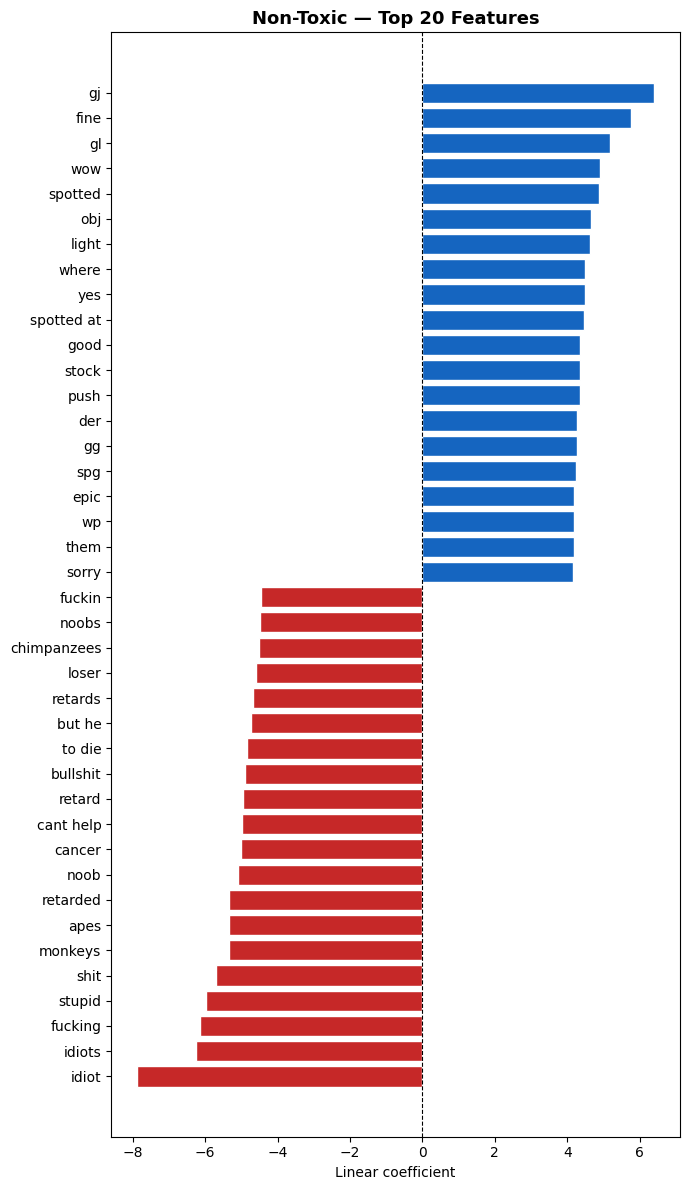

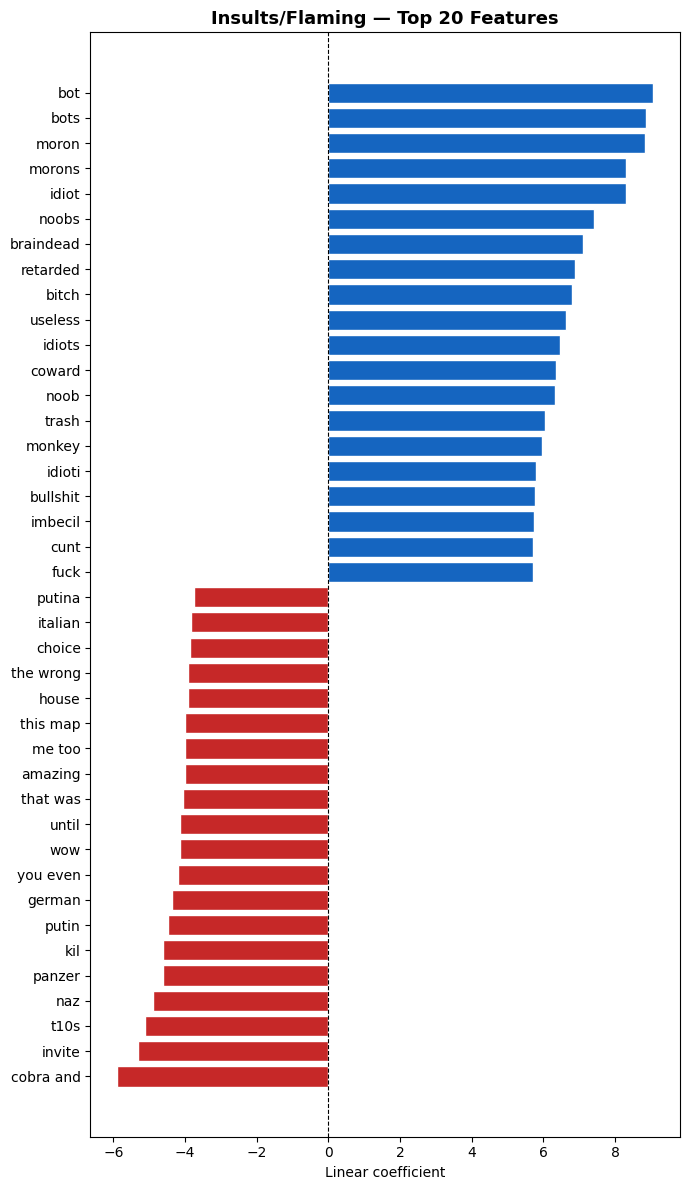

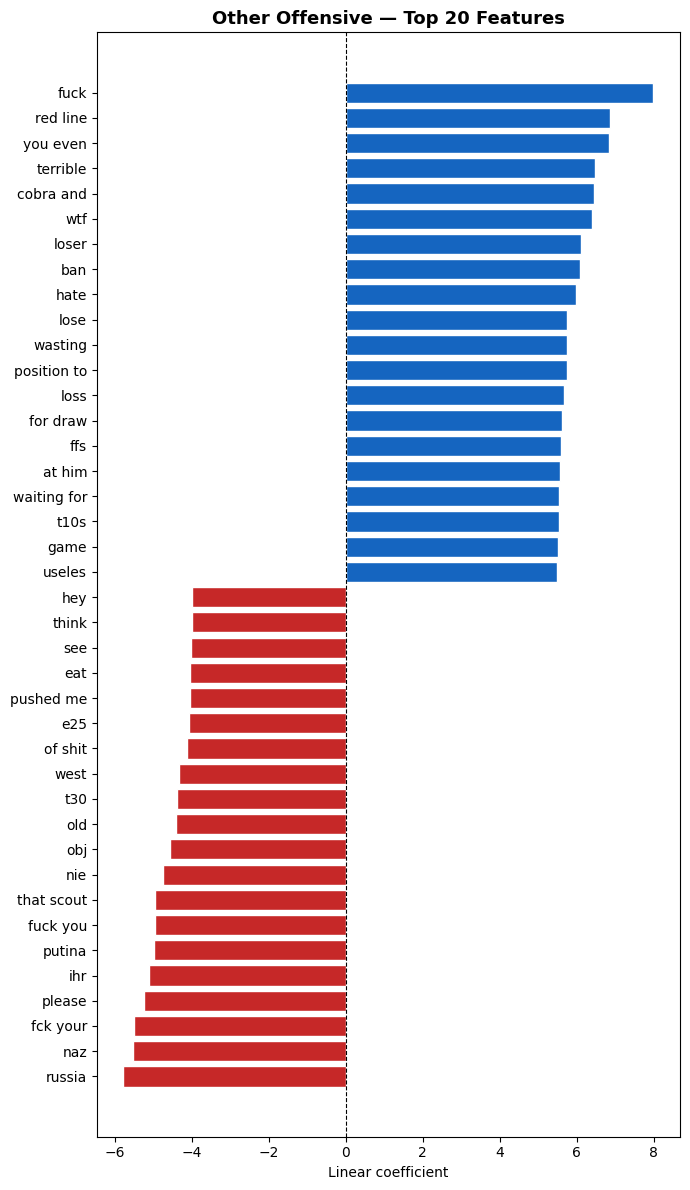

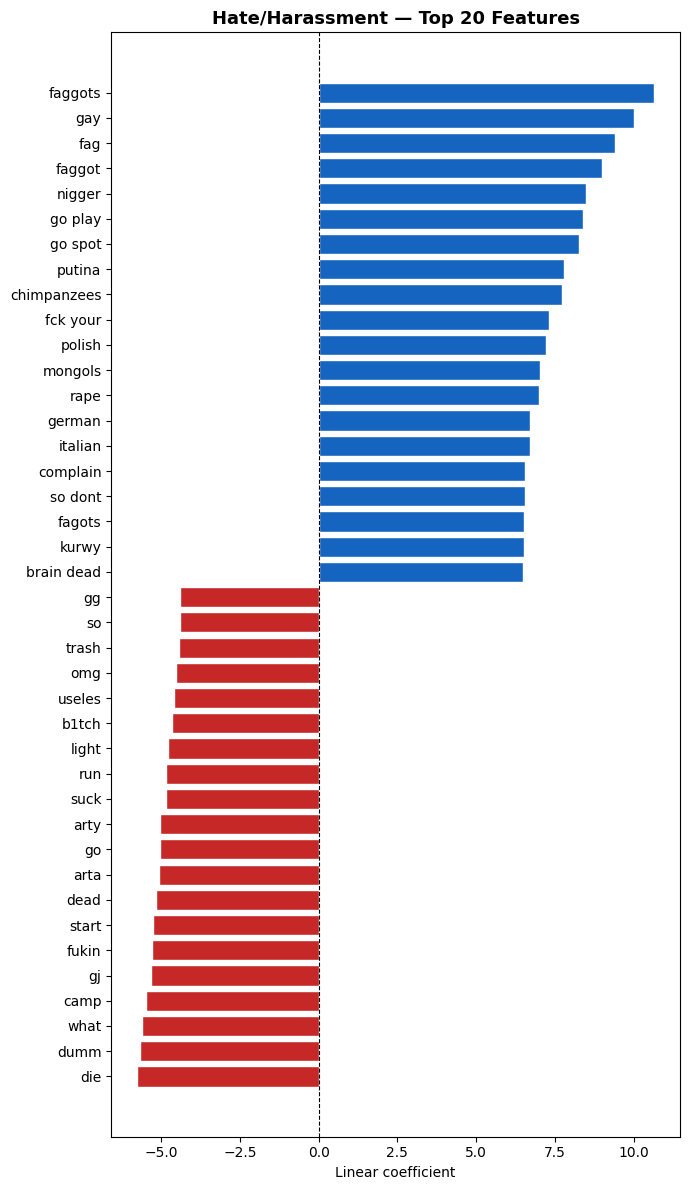

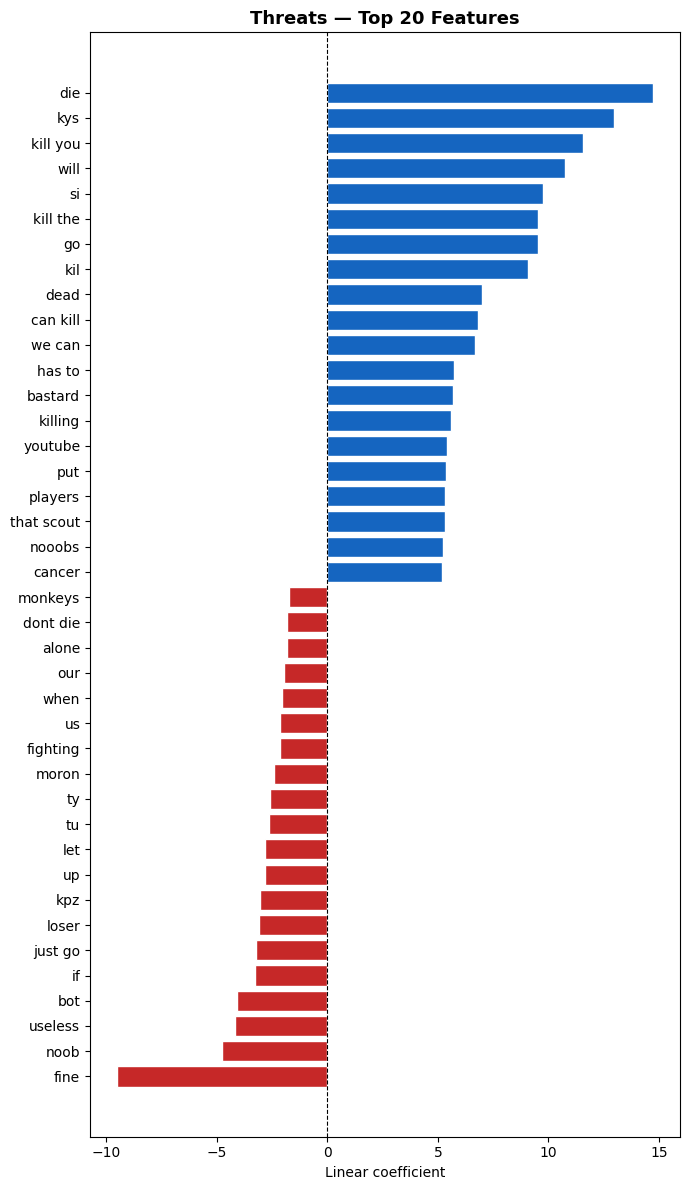

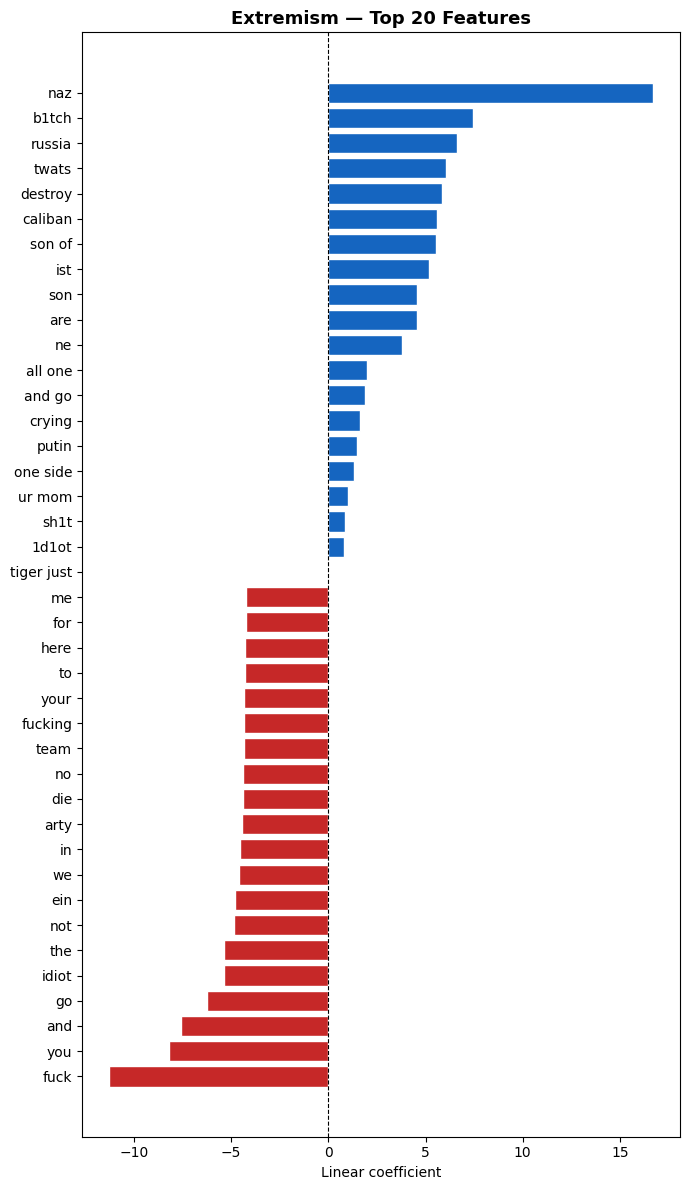

In [39]:
n_top = CONFIG['n_top_features']

for i, cls_name in enumerate(class_names):
    # extract coefficients for current class
    coefs = coef_matrix[i] if coef_matrix.ndim > 1 else coef_matrix[0]

    # get top positive (push toward class) and negative (push away) feature indices
    top_pos = np.argsort(coefs)[-n_top:][::-1]
    top_neg = np.argsort(coefs)[:n_top]

    # combine and sort by descending weight
    idx  = np.concatenate([top_pos, top_neg])
    idx  = idx[np.argsort(coefs[idx])[::-1]]

    # assign colors: blue = positive, red = negative
    vals   = coefs[idx]
    colors = ['#1565C0' if v >= 0 else '#C62828' for v in vals]

    # plot
    fig, ax = plt.subplots(figsize=(7, n_top * 0.6))
    ax.barh(vocab[idx], vals, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{cls_name} — Top {n_top} Features', fontweight='bold', fontsize=13)
    ax.set_xlabel(coef_type, fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 7. Save Best Model — World of Tanks

In [48]:
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

# fit on full training data before saving
best_pipe.fit(X_train, y_train)

model_path = MODELS_DIR / f'wot_{best_model_name.lower().replace(" ", "_")}.joblib'
joblib.dump(best_pipe, model_path)
print(f'Saved: {model_path}')

Saved: ..\models\wot_logistic_regression.joblib


---
## Dota 2 (CONDA)

Same pipeline — oversampling comparison → model selection → test evaluation → interpretability → save.

**Key difference:** 4-class schema (`Other`, `Ego`, `Aggression`, `Impolite`) vs WoT's 6-class.

### 1. Load Data

In [49]:
# 4-class schema for Dota
dota_class_map = {0: 'Other', 1: 'Ego', 2: 'Aggression', 3: 'Impolite'}
dota_class_names = [dota_class_map[i] for i in sorted(dota_class_map)]

# load splits
dota_train_df = pd.read_parquet(d / 'dota_train_ml.parquet')
dota_test_df  = pd.read_parquet(d / 'dota_val_ml.parquet')

X_dota_train, y_dota_train = dota_train_df[tc], dota_train_df[lc].astype(int)
X_dota_test,  y_dota_test  = dota_test_df[tc],  dota_test_df[lc].astype(int)

print(f'Train: {len(X_dota_train):,}  Test: {len(X_dota_test):,}')
for split_name, y_split in [('Train', y_dota_train), ('Test', y_dota_test)]:
    counts = pd.Series(y_split).map(dota_class_map).value_counts()
    print(f'\n--- {split_name} ---')
    for cls, cnt in counts.items():
        print(f'  {cls:<15} {cnt:>5}  ({cnt/len(y_split)*100:.1f}%)')

Train: 24,589  Test: 6,148

--- Train ---
  Other           17910  (72.8%)
  Ego              3606  (14.7%)
  Aggression       1671  (6.8%)
  Impolite         1402  (5.7%)

--- Test ---
  Other            4478  (72.8%)
  Ego               902  (14.7%)
  Aggression        418  (6.8%)
  Impolite          350  (5.7%)


### 2. Oversampling Comparison

In [50]:
dota_reference = LogisticRegression(C=1.0, max_iter=1000, random_state=seed, n_jobs=1)
dota_os_comparison = []

for os_name, sampler in OVERSAMPLERS.items():
    t0 = time.time()
    results = cross_validate(
        ImbPipeline([
            ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
            ('oversample', sampler),
            ('clf',        dota_reference),
        ]),
        X_dota_train, y_dota_train, cv=cv,
        scoring=['f1_macro', 'f1_weighted', 'accuracy'],
        n_jobs=-1, error_score='raise'
    )
    dota_os_comparison.append({
        'Oversampler':    os_name,
        'CV Macro F1':    round(results['test_f1_macro'].mean(), 4),
        'CV Weighted F1': round(results['test_f1_weighted'].mean(), 4),
        'Std':            round(results['test_f1_macro'].std(), 4),
        'Time (s)':       round(time.time() - t0, 1),
    })
    print(f'{os_name:<20}  macro F1 = {results["test_f1_macro"].mean():.4f} +/- {results["test_f1_macro"].std():.4f}')

dota_os_df = pd.DataFrame(dota_os_comparison).sort_values('CV Macro F1', ascending=False).reset_index(drop=True)
dota_os_df

RandomOverSampler     macro F1 = 0.7508 +/- 0.0060
SMOTE                 macro F1 = 0.7461 +/- 0.0076
BorderlineSMOTE       macro F1 = 0.7505 +/- 0.0053
ADASYN                macro F1 = 0.6359 +/- 0.0098


,Oversampler,CV Macro F1,CV Weighted F1,Std,Time (s)
0,RandomOverSampler,0.7508,0.8646,0.0060,3.5
1,BorderlineSMOTE,0.7505,0.8627,0.0053,3.8
2,SMOTE,0.7461,0.8596,0.0076,4.4
3,ADASYN,0.6359,0.7618,0.0098,3.7


### 3. Model Selection & Hyperparameter Tuning

In [64]:
dota_best_os = RandomOverSampler(random_state=seed)
dota_models_comparison = []

# --- Logistic Regression ---
print('--- Logistic Regression (LogisticRegressionCV) ---')
dota_lr_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', dota_best_os),
    ('clf',        LogisticRegressionCV(Cs=30, cv=cv, scoring='f1_macro',
                                        max_iter=1000, random_state=seed, n_jobs=-1)),
])
t0 = time.time()
dota_lr_results = cross_validate(dota_lr_pipe, X_dota_train, y_dota_train, cv=cv,
                                  scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
dota_models_comparison.append({
    'Model':          'Logistic Regression',
    'CV Macro F1':    round(dota_lr_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(dota_lr_results['test_f1_weighted'].mean(), 4),
    'Std':            round(dota_lr_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(dota_models_comparison)

--- Logistic Regression (LogisticRegressionCV) ---


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.7103,0.8409,0.0178,18.5


In [65]:
# apply on test data
score_multiclass(dota_lr_pipe, 
                 X_dota_train, 
                 X_dota_test, 
                 y_dota_train, 
                 y_dota_test)

Test classification report:

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      4478
           1       0.80      0.81      0.80       902
           2       0.62      0.80      0.70       418
           3       0.49      0.68      0.57       350

    accuracy                           0.86      6148
   macro avg       0.71      0.79      0.75      6148
weighted avg       0.87      0.86      0.86      6148



In [66]:
# --- Naive Bayes (Optuna) ---
print('--- Naive Bayes (Optuna TPE) ---')
dota_nb_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', dota_best_os),
    ('clf',        MultinomialNB()),
])

def dota_objective_nb(trial):
    params = {'clf__alpha': trial.suggest_float('clf__alpha', 0.001, 2.0, log=True)}
    pipe = clone(dota_nb_pipe)
    pipe.set_params(**params)
    return cross_val_score(pipe, X_dota_train, y_dota_train, cv=cv,
                           scoring=CONFIG['scoring'], n_jobs=1).mean()

dota_study_nb = start_study_optuna(dota_objective_nb, n_trials=CONFIG['optuna_trials'], seed=seed)
dota_nb_pipe.set_params(**dota_study_nb.best_params)

t0 = time.time()
dota_nb_results = cross_validate(dota_nb_pipe, X_dota_train, y_dota_train, cv=cv,
                                  scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
dota_models_comparison.append({
    'Model':          'Naive Bayes',
    'CV Macro F1':    round(dota_nb_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(dota_nb_results['test_f1_weighted'].mean(), 4),
    'Std':            round(dota_nb_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(dota_models_comparison)

--- Naive Bayes (Optuna TPE) ---
Best params: {'clf__alpha': 1.76838614860104}


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.7103,0.8409,0.0178,18.5
1,Naive Bayes,0.6308,0.7648,0.0080,0.2


In [67]:
# apply on test data
score_multiclass(dota_nb_pipe, 
                 X_dota_train, 
                 X_dota_test, 
                 y_dota_train, 
                 y_dota_test)

Test classification report:

              precision    recall  f1-score   support

           0       0.94      0.75      0.83      4478
           1       0.63      0.80      0.71       902
           2       0.43      0.83      0.57       418
           3       0.36      0.68      0.47       350

    accuracy                           0.76      6148
   macro avg       0.59      0.76      0.64      6148
weighted avg       0.83      0.76      0.78      6148



In [68]:
# --- LinearSVC ---
print('--- LinearSVC ---')
dota_svc_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', dota_best_os),
    ('clf',        LinearSVC(C=1.0, max_iter=2000, tol=1e-3, random_state=seed)),
])
t0 = time.time()
dota_svc_results = cross_validate(dota_svc_pipe, X_dota_train, y_dota_train, cv=cv,
                                   scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
dota_models_comparison.append({
    'Model':          'LinearSVC',
    'CV Macro F1':    round(dota_svc_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(dota_svc_results['test_f1_weighted'].mean(), 4),
    'Std':            round(dota_svc_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(dota_models_comparison)

--- LinearSVC ---


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.7103,0.8409,0.0178,18.5
1,Naive Bayes,0.6308,0.7648,0.0080,0.2
2,LinearSVC,0.7215,0.8457,0.0075,1.1


In [69]:
# apply on test data
score_multiclass(dota_svc_pipe, 
                 X_dota_train, 
                 X_dota_test, 
                 y_dota_train, 
                 y_dota_test)

Test classification report:

              precision    recall  f1-score   support

           0       0.94      0.87      0.91      4478
           1       0.80      0.82      0.81       902
           2       0.62      0.80      0.70       418
           3       0.46      0.69      0.55       350

    accuracy                           0.85      6148
   macro avg       0.70      0.79      0.74      6148
weighted avg       0.87      0.85      0.86      6148



In [70]:
dota_compare_df = pd.DataFrame(dota_models_comparison).sort_values('CV Macro F1', ascending=False).reset_index(drop=True)
print(dota_compare_df)

DOTA_MODELS = {
    'Logistic Regression': dota_lr_pipe,
    'Naive Bayes':         dota_nb_pipe,
    'LinearSVC':           dota_svc_pipe,
}
dota_best_model_name = dota_compare_df.iloc[0]['Model']
dota_best_pipe       = DOTA_MODELS[dota_best_model_name]
print(f'\nBest model: {dota_best_model_name}')



                 Model  CV Macro F1  CV Weighted F1     Std  Time (s)
0            LinearSVC       0.7215          0.8457  0.0075       1.1
1  Logistic Regression       0.7103          0.8409  0.0178      18.5
2          Naive Bayes       0.6308          0.7648  0.0080       0.2

Best model: LinearSVC


### 5. Interpretability

Model type: LinearSVC
Vocabulary size: 5,395
Coefficient matrix shape: (4, 5395)  (n_classes x n_features)


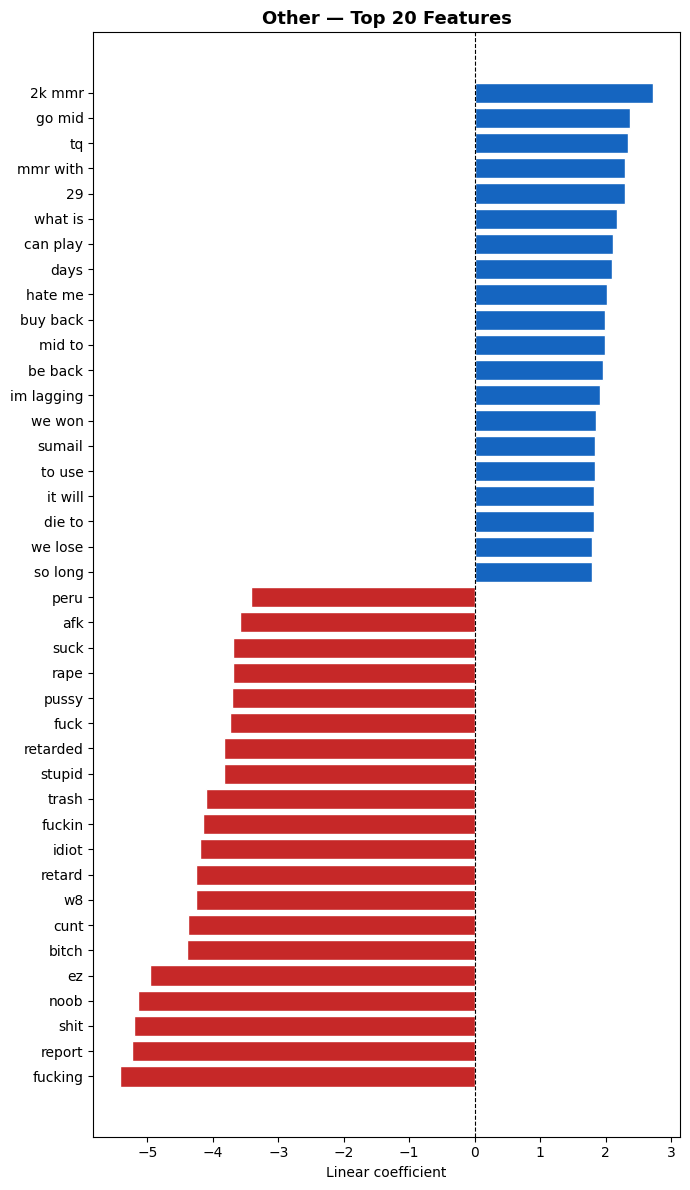

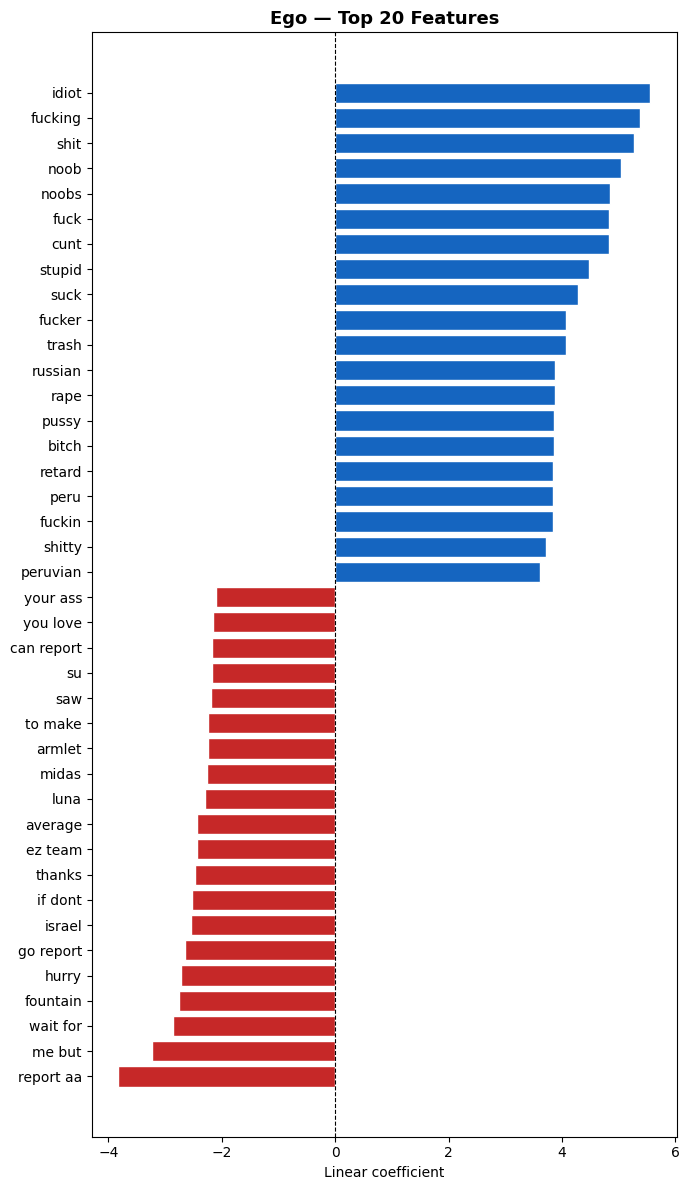

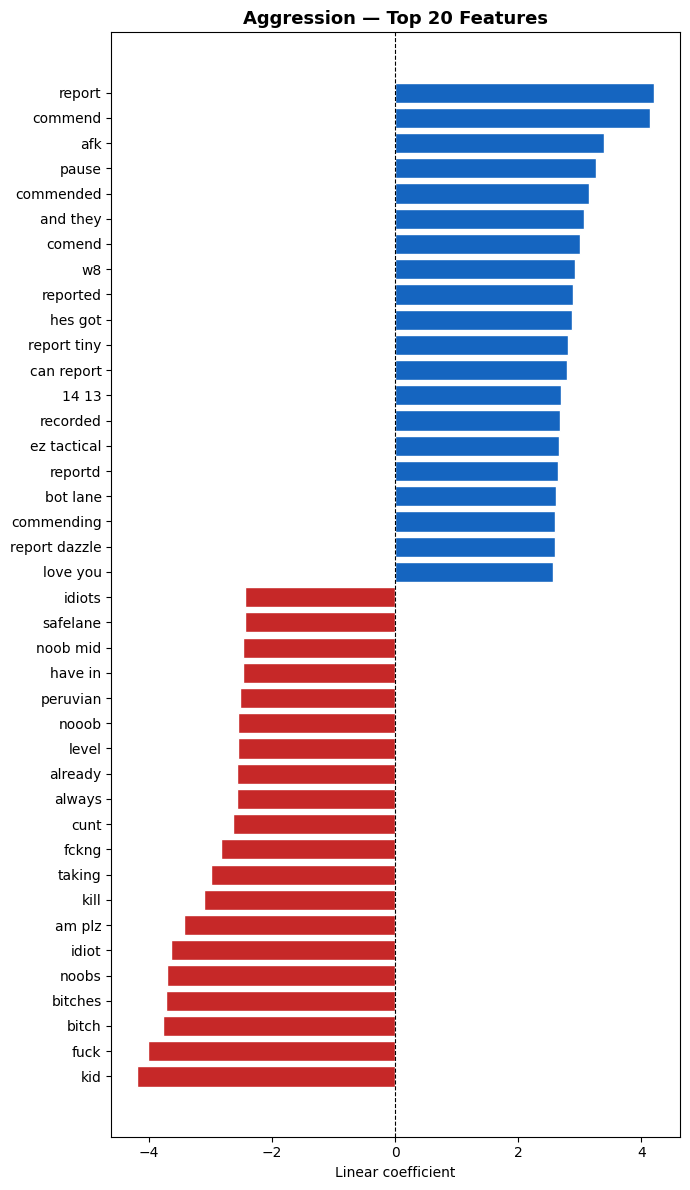

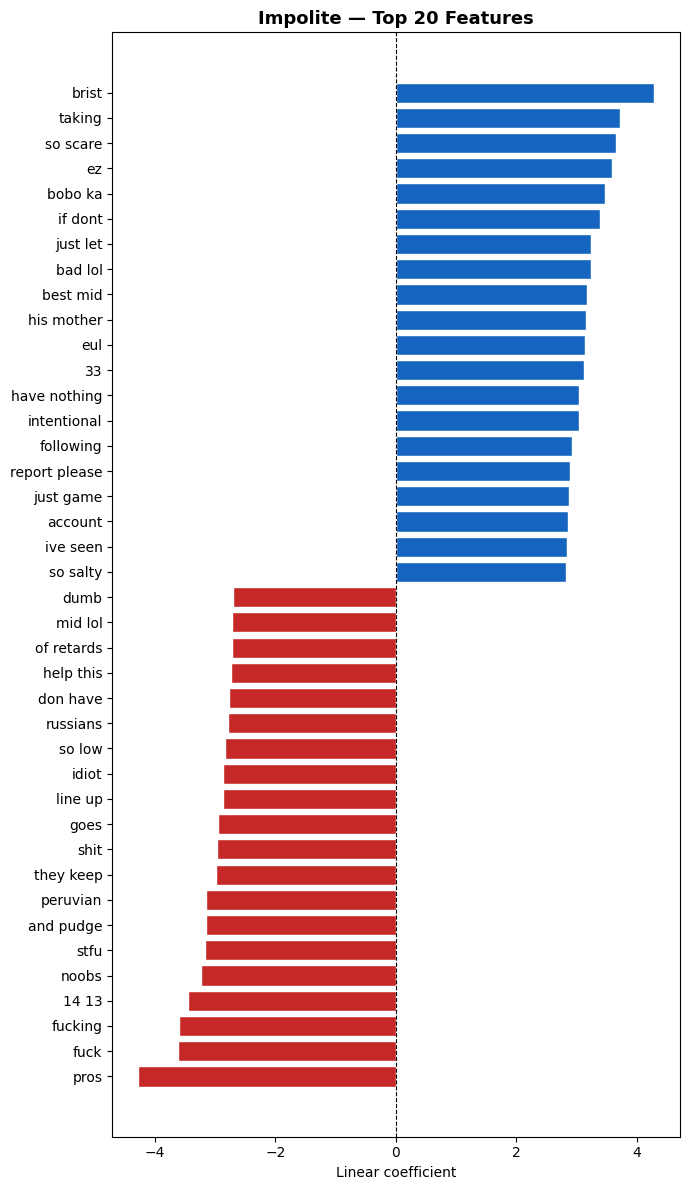

In [71]:
dota_clf   = dota_best_pipe.named_steps['clf']
dota_tfidf = dota_best_pipe.named_steps['tfidf']
dota_vocab = np.array(dota_tfidf.get_feature_names_out())

print(f'Model type: {type(dota_clf).__name__}')
print(f'Vocabulary size: {len(dota_vocab):,}')

if hasattr(dota_clf, 'coef_'):
    dota_coef_matrix = np.array(dota_clf.coef_)
    dota_coef_type   = 'Linear coefficient'
elif hasattr(dota_clf, 'feature_log_prob_'):
    dota_coef_matrix = np.array(dota_clf.feature_log_prob_)
    dota_coef_type   = 'Log probability'
else:
    raise ValueError(f'Cannot extract feature importances from {type(dota_clf).__name__}')

print(f'Coefficient matrix shape: {dota_coef_matrix.shape}  (n_classes x n_features)')

n_top = CONFIG['n_top_features']
for i, cls_name in enumerate(dota_class_names):
    coefs   = dota_coef_matrix[i] if dota_coef_matrix.ndim > 1 else dota_coef_matrix[0]
    top_pos = np.argsort(coefs)[-n_top:][::-1]
    top_neg = np.argsort(coefs)[:n_top]
    idx     = np.concatenate([top_pos, top_neg])
    idx     = idx[np.argsort(coefs[idx])[::-1]]
    vals    = coefs[idx]
    colors  = ['#1565C0' if v >= 0 else '#C62828' for v in vals]

    fig, ax = plt.subplots(figsize=(7, n_top * 0.6))
    ax.barh(dota_vocab[idx], vals, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{cls_name} — Top {n_top} Features', fontweight='bold', fontsize=13)
    ax.set_xlabel(dota_coef_type, fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

### 6. Save Best Model — Dota 2

In [72]:
dota_model_path = MODELS_DIR / f'dota_{dota_best_model_name.lower().replace(" ", "_")}.joblib'
joblib.dump(dota_best_pipe, dota_model_path)
print(f'Saved: {dota_model_path}')

Saved: ..\models\dota_linearsvc.joblib
